# LT heat pump (R245fa) -- TESPy model
## Based on: Energie-Wende-Garching (EWG) high-temperature heat pump project

This notebook builds a standalone R245fa heat pump, compressed with a
**constant isentropic efficiency**.

```
geo source (47 degC) -> Evaporator -> geo sink (40 degC)

 1  -> compressor suction   (sat. vapour + superheat, low pressure)
 2  -> compressor discharge (superheated, high pressure)
 3  -> condenser outlet     (subcooled liquid, high pressure)
 4  -> expansion valve outlet -> evaporator inlet (low pressure, two-phase)
 1  -> closes the cycle at the evaporator outlet

sink-in (55 degC) -> condenser (cold side) -> sink-out (63 degC)
```

**Design point** (from the geo source spec: 47 -> 40 degC, 100 kg/s):

| | LT loop |
|---|---|
| Evaporates at | 30 degC (5 K superheat) |
| Condenses at | 68 degC (3 K subcool) |
| Pressure ratio | approx 3.24 |
| Compressor eta_s (constant) | 0.75 |




## 1. Imports

In [1]:
from tespy.networks import Network
from tespy.components import (
    Source, Sink, Compressor, Valve, SectionedHeatExchanger, CycleCloser
)
from tespy.connections import Connection

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


## 2. Network and units

In [2]:
nw = Network()
nw.units.set_defaults(
    temperature='degC', pressure='bar', pressure_difference='bar',
    enthalpy='kJ/kg', mass_flow='kg/s', power='kW', heat='kW'
)


## 3. Components

In [3]:
cc = CycleCloser('cycle closer')

compressor = Compressor('LT compressor (R245fa)')
condenser = SectionedHeatExchanger('LT condenser')
valve = Valve('LT expansion valve')
evaporator = SectionedHeatExchanger('LT evaporator')

geo_source = Source('geothermal source')     # point C, 47 degC
geo_sink = Sink('geothermal sink')           # point D, 40 degC

sink_source = Source('heat sink in')
sink_sink = Sink('heat sink out')


## 4. Connections -> working fluid loop (R245fa)

In [4]:
c1 = Connection(cc, 'out1', compressor, 'in1', label='1')          # compressor suction
c2 = Connection(compressor, 'out1', condenser, 'in1', label='2')   # compressor discharge
c3 = Connection(condenser, 'out1', valve, 'in1', label='3')        # subcooled liquid
c4 = Connection(valve, 'out1', evaporator, 'in2', label='4')       # evaporator inlet
c1b = Connection(evaporator, 'out2', cc, 'in1', label='1b')        # closes the cycle at state 1

nw.add_conns(c1, c2, c3, c4, c1b)


## 5. Connections -> geothermal source side (evaporator, hot side)

In [5]:
gC = Connection(geo_source, 'out1', evaporator, 'in1', label='C')
gD = Connection(evaporator, 'out1', geo_sink, 'in1', label='D')

nw.add_conns(gC, gD)


## 6. Connections -> heat sink (condenser, cold side)

In [6]:
d1 = Connection(sink_source, 'out1', condenser, 'in2', label='sink-in')
d2 = Connection(condenser, 'out2', sink_sink, 'in1', label='sink-out')

nw.add_conns(d1, d2)


## 7. Refrigerant-side design point (temperatures & pressures)

Pressure levels set directly from target saturation temperatures, as before.


In [7]:
FLUID = 'R245fa'
T_evap = 30       # degC, saturation temperature in the evaporator
T_cond = 68       # degC, saturation temperature in the condenser
superheat = 5     # K, suction superheat (dry-compression margin)
subcool = 3        # K, liquid subcooling ahead of the expansion valve

p_evap = PropsSI('P', 'T', T_evap + 273.15, 'Q', 1, FLUID) / 1e5   # bar
p_cond = PropsSI('P', 'T', T_cond + 273.15, 'Q', 0, FLUID) / 1e5   # bar

print(f'p_evap = {p_evap:.3f} bar, p_cond = {p_cond:.3f} bar, pr = {p_cond / p_evap:.2f}')


p_evap = 1.781 bar, p_cond = 5.775 bar, pr = 3.24


In [8]:
evaporator.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

gC.set_attr(fluid={'water': 1}, T=47, p=5, m=100)   # geothermal inlet: 47 degC, 100 kg/s (EWG doc)
gD.set_attr(T=40)                                   # geothermal outlet: 40 degC (EWG doc)


## 9. Parameters -> heat sink side (condenser, cold side)

In [9]:
condenser.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

d1.set_attr(fluid={'water': 1}, T=55, p=5)   # heat sink inlet
d2.set_attr(T=63)                            # heat sink outlet


In [10]:
compressor.set_attr(eta_s=0.75)   # constant isentropic efficiency (placeholder -- adjust as needed)

c1.set_attr(fluid={FLUID: 1}, p=p_evap, td_dew=superheat)   # mass flow left FREE (see Section 8)
c2.set_attr(p=p_cond)
c3.set_attr(td_bubble=subcool)


## 11. Solve

In [11]:
nw.solve('design')
nw.print_results()


 block   0 | scalar          | iterations:   2 | residual: 4.21e-17 | LT compressor (R245fa).eta_s
 block   1 | scalar          | iterations:   3 | residual: 9.22e-14 | LT evaporator.energy_balance_constraints
 block   2 | scalar          | iterations:   2 | residual: 7.96e-15 | LT condenser.energy_balance_constraints



##### RESULTS (Compressor) #####
+------------------------+----------+----------+-----------+----------+
|                        |        P |       pr |        dp |    eta_s |
|------------------------+----------+----------+-----------+----------|
| LT compressor (R245fa) | 5.76e+02 | 3.24e+00 | -3.99e+00 | 7.50e-01 |
+------------------------+----------+----------+-----------+----------+
##### RESULTS (SectionedHeatExchanger) #####
+---------------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+----------+----------+------------+----------+------------+----------+-----------+------------+-----------+------------+
|               |         Q |       UA |       kA |   td_log |     lmtd |    ttd_u |    ttd_l |   ttd_min |      pr1 |      pr2 |      dp1 |      dp2 |   zeta1_d4 |    zeta1 |   zeta2_d4 |    zeta2 |   eff_hot |   eff_cold |   eff_max |   td_pinch |
|---------------+-----------+----------+----------+----------

## 12. Pinch-point check

In [12]:
print('Refrigerant (R245fa) mass flow rate:', round(c1.m.val, 3), 'kg/s')
print('Geothermal mass flow rate (RESULT):', round(gC.m.val, 2), 'kg/s')
print()
print(f"{'Component':<15}{'ttd_u [K]':>12}{'ttd_l [K]':>12}")
for hx in [evaporator, condenser]:
    flag_u = '  <-- violation!' if hx.ttd_u.val < 0 else ''
    flag_l = '  <-- violation!' if hx.ttd_l.val < 0 else ''
    print(f"{hx.label:<15}{hx.ttd_u.val:>12.2f}{hx.ttd_l.val:>12.2f}"
          f"{flag_u if hx.ttd_u.val < 0 else flag_l}")

if c2.x.val < 1:
    print()
    print(f'NOTE: compressor discharge quality x = {c2.x.val:.3f} (< 1) -- wet compression. '
          'Increase `superheat` in Section 7 and re-run from there.')
else:
    print()
    print(f'Discharge is dry (T={c2.T.val:.1f} degC vs. T_cond={T_cond} degC, '
          f'{c2.T.val - T_cond:.1f} K of superheat at the outlet).')


Refrigerant (R245fa) mass flow rate: 20.219 kg/s
Geothermal mass flow rate (RESULT): 100.0 kg/s

Component         ttd_u [K]   ttd_l [K]
LT evaporator         12.00       10.00
LT condenser          10.21       10.00

Discharge is dry (T=73.2 degC vs. T_cond=68 degC, 5.2 K of superheat at the outlet).


## 13. Key results

In [13]:
P_comp = compressor.P.val
Q_evap = evaporator.Q.val
Q_cond = condenser.Q.val

Q_useful = -Q_cond   # kW, heat delivered to the sink
COP = Q_useful / P_comp
pr = c2.p.val / c1.p.val

print('================ LT LOOP SUMMARY ================')
print(f'Refrigerant                  : {FLUID}')
print(f'Refrigerant mass flow rate   : {c1.m.val:8.2f} kg/s')
print(f'Pressure ratio                : {pr:8.2f}')
print(f'Isentropic efficiency         : {compressor.eta_s.val * 100:8.2f} %')
print(f'Compressor discharge temp.    : {c2.T.val:8.1f} degC')
print(f'Compressor power              : {P_comp:8.1f} kW')
print(f'Evaporator duty               : {-Q_evap:8.1f} kW')
print(f'Condenser duty (-> sink)       : {Q_useful:8.1f} kW')
print(f'COP (LT loop only)            : {COP:8.2f}')


================ LT LOOP SUMMARY ================
Refrigerant                  : R245fa
Refrigerant mass flow rate   :    20.22 kg/s
Pressure ratio                :     3.24
Isentropic efficiency         :    75.00 %
Compressor discharge temp.    :     73.2 degC
Compressor power              :    575.7 kW
Evaporator duty               :   2925.3 kW
Condenser duty (-> sink)       :   3501.0 kW
COP (LT loop only)            :     6.08


## 14. T-s diagram and T-Q diagrams

Same plotting code as before, now against the 30/68 degC design point.


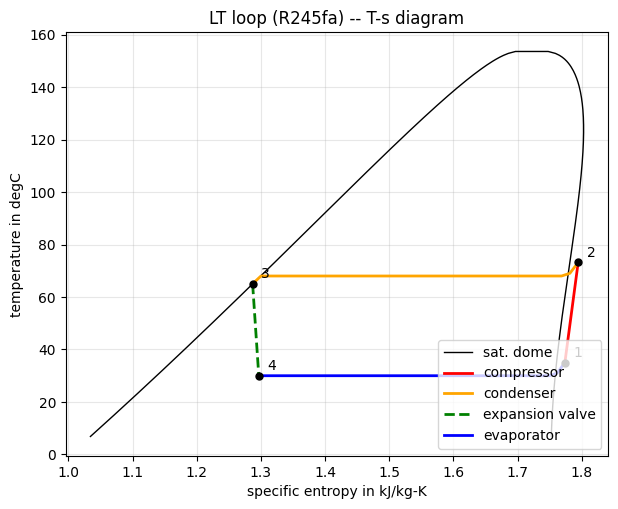

In [14]:
def conn_Ts(conn):
    p_Pa = conn.p.val * 1e5
    h_Jkg = conn.h.val * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', h_Jkg, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', h_Jkg, FLUID) / 1e3
    return T, s


def isobar_Ts(p_bar, h1_kJkg, h2_kJkg, n=40):
    p_Pa = p_bar * 1e5
    hs = np.linspace(h1_kJkg, h2_kJkg, n) * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', hs, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', hs, FLUID) / 1e3
    return T, s


T_crit = PropsSI('Tcrit', FLUID)
T_dome = np.linspace(280, T_crit - 0.3, 200)
sf = PropsSI('S', 'T', T_dome, 'Q', 0, FLUID) / 1e3
sg = PropsSI('S', 'T', T_dome, 'Q', 1, FLUID) / 1e3
T_dome_C = T_dome - 273.15

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(np.concatenate([sf, sg[::-1]]), np.concatenate([T_dome_C, T_dome_C[::-1]]),
        'k-', lw=1, label='sat. dome')

states = {'1': c1, '2': c2, '3': c3, '4': c4}
pts = {k: conn_Ts(v) for k, v in states.items()}

ax.plot([pts['1'][1], pts['2'][1]], [pts['1'][0], pts['2'][0]], 'r-', lw=2, label='compressor')
T23, s23 = isobar_Ts(c2.p.val, c2.h.val, c3.h.val)
ax.plot(s23, T23, 'orange', lw=2, label='condenser')
ax.plot([pts['3'][1], pts['4'][1]], [pts['3'][0], pts['4'][0]], 'g--', lw=2, label='expansion valve')
T41, s41 = isobar_Ts(c4.p.val, c4.h.val, c1.h.val)
ax.plot(s41, T41, 'b-', lw=2, label='evaporator')

for k, (T, s) in pts.items():
    ax.plot(s, T, 'ko', ms=5)
    ax.annotate(k, (s, T), textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('specific entropy in kJ/kg-K')
ax.set_ylabel('temperature in degC')
ax.set_title('LT loop (R245fa) -- T-s diagram')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()


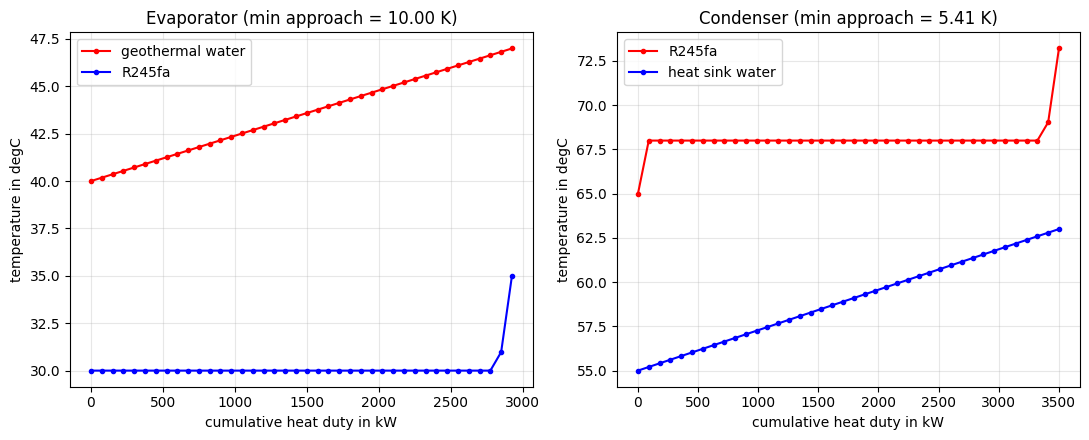

In [15]:
def counter_current_profile(m_hot, fluid_hot, p_hot_in_bar, p_hot_out_bar, h_hot_in, h_hot_out,
                             m_cold, fluid_cold, p_cold_in_bar, p_cold_out_bar, h_cold_in, h_cold_out,
                             n=40):
    Q_total = m_cold * (h_cold_out - h_cold_in)  # kW
    Q = np.linspace(0, Q_total, n)
    h_cold = h_cold_in + Q / m_cold
    h_hot = h_hot_out + Q / m_hot
    p_cold = np.linspace(p_cold_in_bar, p_cold_out_bar, n) * 1e5
    p_hot = np.linspace(p_hot_out_bar, p_hot_in_bar, n) * 1e5
    T_cold = PropsSI('T', 'P', p_cold, 'H', h_cold * 1e3, fluid_cold) - 273.15
    T_hot = PropsSI('T', 'P', p_hot, 'H', h_hot * 1e3, fluid_hot) - 273.15
    return Q, T_hot, T_cold


fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

Q, Th, Tc = counter_current_profile(
    gC.m.val, 'water', gC.p.val, gD.p.val, gC.h.val, gD.h.val,
    c4.m.val, FLUID, c4.p.val, c1.p.val, c4.h.val, c1.h.val)
axs[0].plot(Q, Th, 'r-o', ms=3, label='geothermal water')
axs[0].plot(Q, Tc, 'b-o', ms=3, label=FLUID)
axs[0].set_title(f'Evaporator (min approach = {(Th - Tc).min():.2f} K)')
axs[0].set_xlabel('cumulative heat duty in kW')
axs[0].set_ylabel('temperature in degC')
axs[0].legend()
axs[0].grid(alpha=0.3)

Q, Th, Tc = counter_current_profile(
    c2.m.val, FLUID, c2.p.val, c3.p.val, c2.h.val, c3.h.val,
    d1.m.val, 'water', d1.p.val, d2.p.val, d1.h.val, d2.h.val)
axs[1].plot(Q, Th, 'r-o', ms=3, label=FLUID)
axs[1].plot(Q, Tc, 'b-o', ms=3, label='heat sink water')
axs[1].set_title(f'Condenser (min approach = {(Th - Tc).min():.2f} K)')
axs[1].set_xlabel('cumulative heat duty in kW')
axs[1].set_ylabel('temperature in degC')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
